In [2]:
!wget -O caltech-101.zip https://data.caltech.edu/records/mzrjq-6wc36/files/caltech-101.zip
!unzip -q caltech-101.zip

--2026-09-14 08:53:35--  https://data.caltech.edu/records/mzrjq-6wc36/files/caltech-101.zip
Resolving data.caltech.edu (data.caltech.edu)... 104.18.36.210, 172.64.151.46, 2a06:98c1:3104::ac40:972e, ...
Connecting to data.caltech.edu (data.caltech.edu)|104.18.36.210|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-14 08:53:35 ERROR 404: Not Found.

[caltech-101.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of caltech-101.zip or
        caltech-101.zip.zip, and cannot find caltech-101.zip.ZIP, period.


In [10]:
import torchvision
dataset = torchvision.datasets.Caltech101(root='./', download=True)

100%|██████████| 137M/137M [00:02<00:00, 48.3MB/s]


In [11]:
import os
import requests
import zipfile




# Creating the directory structure expected by your notebook
dataset_path = '/content/caltech101/101_ObjectCategories'
os.makedirs(dataset_path, exist_ok=True)

print(f"Target directory created: {dataset_path}")


Target directory created: /content/caltech101/101_ObjectCategories


In [12]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F

In [13]:
import os
import torch
import torch.nn as nn
import numpy as np
import hashlib

def gabor_filter(size, sigma, lambd, theta_deg, gamma=0.3):
    theta = np.deg2rad(theta_deg)
    half_size = size // 2
    y, x = np.meshgrid(range(-half_size, half_size + 1), range(-half_size, half_size + 1))
    X = x * np.cos(theta) + y * np.sin(theta)
    Y = -x * np.sin(theta) + y * np.cos(theta)
    envelope = np.exp(-(X**2 + (gamma**2) * Y**2) / (2 * sigma**2))
    carrier = np.cos(2 * np.pi * X / lambd)
    return envelope * carrier

class FullS1Layer(nn.Module):
    def __init__(self, cache_dir="s1_cache"):
        super().__init__()
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

        self.orientations = [0, 45, 90, 135]
        self.bands = [
            {"sizes": [7, 9], "sigmas": [2.8, 3.6], "lambdas": [3.5, 4.6]},
            {"sizes": [11, 13], "sigmas": [4.5, 5.4], "lambdas": [5.6, 6.8]},
            {"sizes": [15, 17], "sigmas": [6.3, 7.3], "lambdas": [7.9, 9.1]},
            {"sizes": [19, 21], "sigmas": [8.2, 9.2], "lambdas": [10.3, 11.5]},
            {"sizes": [23, 25], "sigmas": [10.2, 11.3], "lambdas": [12.7, 14.1]},
            {"sizes": [27, 29], "sigmas": [12.3, 13.4], "lambdas": [15.4, 16.8]},
            {"sizes": [31, 33], "sigmas": [14.6, 15.8], "lambdas": [18.2, 19.7]},
            {"sizes": [35, 37], "sigmas": [17.0, 18.2], "lambdas": [21.2, 22.8]}
        ]

        self.filters = nn.ModuleList()
        for band in self.bands:
            for i in range(2):
                size = band["sizes"][i]
                sigma = band["sigmas"][i]
                lambd = band["lambdas"][i]
                for ori in self.orientations:
                    gabor = gabor_filter(size, sigma, lambd, ori)
                    conv = nn.Conv2d(1, 1, kernel_size=size, padding=size // 2, bias=False)
                    conv.weight.data[0, 0] = torch.Tensor(gabor).float()
                    conv.weight.requires_grad = False
                    self.filters.append(conv)

    def _get_cache_path(self, x):
        h = hashlib.md5(x.cpu().numpy().tobytes()).hexdigest()
        return os.path.join(self.cache_dir, f"{h}.pt")

    def forward(self, x):
        cache_path = self._get_cache_path(x)
        if os.path.exists(cache_path):
            return torch.load(cache_path)

        outputs = [torch.abs(filt(x)) for filt in self.filters]
        torch.save(outputs, cache_path)
        return outputs

In [14]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import hashlib

class C1Layer(nn.Module):
    def __init__(self, ns_values=None, stride_ratio=0.5, cache_dir="c1_cache"):
        super().__init__()
        self.num_orientations = 4
        self.scales_per_orientation = 16
        self.ns_values = ns_values if ns_values is not None else [8, 10, 12, 14, 16, 18, 20, 22]
        self.stride_ratio = stride_ratio
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

    def _get_cache_path(self, s1_outputs):
        all_data = torch.cat([s.cpu().flatten() for s in s1_outputs])
        h = hashlib.md5(all_data.numpy().tobytes()).hexdigest()
        return os.path.join(self.cache_dir, f"{h}.pt")

    def forward(self, s1_outputs):
        cache_path = self._get_cache_path(s1_outputs)
        if os.path.exists(cache_path):
            return torch.load(cache_path)

        c1_maps = []
        for ori in range(self.num_orientations):
            start = ori * self.scales_per_orientation
            s1_ori_maps = s1_outputs[start:start + self.scales_per_orientation]

            for band in range(8):
                s1_1 = s1_ori_maps[2 * band]
                s1_2 = s1_ori_maps[2 * band + 1]

                assert s1_1.shape == s1_2.shape, f"mismatched S1 maps in orientation {ori}, band {band}"
                band_max = torch.max(s1_1, s1_2)
                c1_maps.append(band_max)

        c1_pooled_maps = []
        for i, c1_map in enumerate(c1_maps):
            band_idx = i % 8
            ns = self.ns_values[band_idx]
            stride = max(1, int(ns * self.stride_ratio))
            h, w = c1_map.shape[-2], c1_map.shape[-1]
            if h < ns or w < ns:
                print(f"C1 map too small for pooling (band {band_idx}): map=({h},{w}), ns={ns}")

            pooled = F.max_pool2d(c1_map, kernel_size=ns, stride=stride, padding=0)
            print(f"Band {i} | C1 map shape: {c1_map.shape} → Pooled: {pooled.shape}")
            c1_pooled_maps.append(pooled)

        torch.save(c1_pooled_maps, cache_path)
        return c1_pooled_maps


In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def check_input_tensor(x, s1_layer):

    # norm?
    min_val = x.min().item()
    max_val = x.max().item()
    print(f"  Range: [{min_val:.3f}, {max_val:.3f}]")
    if min_val < 0 or max_val > 1:
        print("  Input not normalized to [0, 1]!")

    # data type?
    print(f"   Dtype: {x.dtype}")
    if x.dtype != torch.float32:
        print("  Input is not float32!")

    # data shape?
    print(f"   Shape: {x.shape}")
    if len(x.shape) != 4 or x.shape[1] != 1:
        print("  Input should have shape (B, 1, H, W)!")

    print(" completed.\n")

def preprocess_image(img_path):
    """
    Convert image to grayscale, resize height to 140, adjust width proportionally, return tensor.
    """
    img = Image.open(img_path).convert('L')
    w, h = img.size
    new_h = 140
    new_w = int((new_h / h) * w)
    img = img.resize((new_w, new_h), Image.BILINEAR)

    img_tensor = torch.tensor(np.array(img), dtype=torch.float32) / 255.0
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # B x 1 x H x W
    return img_tensor


def visualize_tensor(tensor, title, idx=0):
    arr = tensor[idx, 0].detach().cpu().numpy()
    plt.imshow(arr, cmap='gray')
    plt.title(title)
    plt.axis('off')

def test_s1_c1_pipeline(img_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #  Preprocess image
    x = preprocess_image(img_path).to(device)

    # Run S1
    s1_layer = FullS1Layer().to(device)
    with torch.no_grad():
        s1_outputs = s1_layer(x)

    # Visualize a few S1 outputs
    plt.figure(figsize=(10, 4))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        visualize_tensor(s1_outputs[i], f'S1 Output {i}')
    plt.suptitle('Sample S1 Outputs')
    plt.show()

    # Run C1
    c1_layer = C1Layer().to(device)
    with torch.no_grad():
        c1_outputs = c1_layer(s1_outputs)

    # Visualize a few C1 outputs
    plt.figure(figsize=(10, 4))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        visualize_tensor(c1_outputs[i], f'C1 Output {i}')
    plt.suptitle('Sample C1 Outputs')
    plt.show()

    #  Also show the original image
    plt.figure()
    plt.imshow(x[0, 0].cpu(), cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

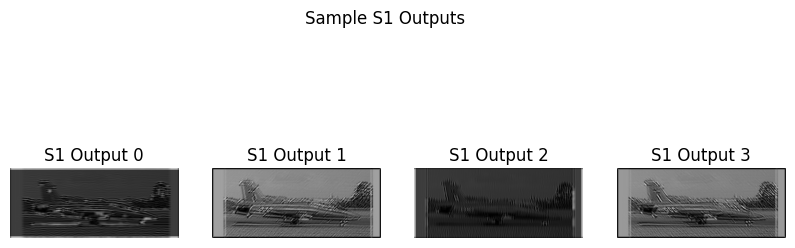

Band 0 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 34, 83])
Band 1 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 27, 66])
Band 2 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 22, 55])
Band 3 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 19, 47])
Band 4 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 16, 41])
Band 5 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 14, 36])
Band 6 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 13, 32])
Band 7 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 11, 29])
Band 8 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 34, 83])
Band 9 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 27, 66])
Band 10 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 22, 55])
Band 11 | C1 map sha

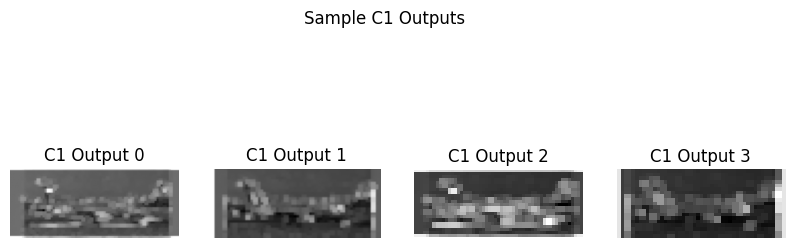

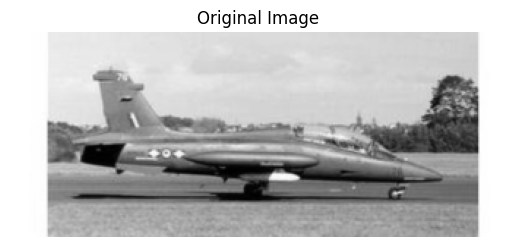

In [17]:
test_s1_c1_pipeline("/content/caltech101/101_ObjectCategories/airplanes/image_0001.jpg")


In [18]:
import random
def build_four_orientation_patch_pool(
    c1_maps, total_patches=1000, patch_sizes=(4, 8, 12, 16), max_tries=50_000
):
    """
    Returns
    --------
    patches : list[Tensor]   each  [4, ps, ps]
    meta    : list[dict]
    """
    ori_band = [[c1_maps[ori*8 + b] for b in range(8)] for ori in range(4)]
    band_hw  = [ori_band[0][b].shape[2:] for b in range(8)]

    patches, meta, tries = [], [], 0
    while len(patches) < total_patches and tries < max_tries:
        tries += 1
        ps = random.choice(patch_sizes)

        valid_bands = [b for b,(H,W) in enumerate(band_hw) if H >= ps and W >= ps]
        if not valid_bands:
            continue
        band = random.choice(valid_bands)
        H, W = band_hw[band]

        y = random.randint(0, H-ps)
        x = random.randint(0, W-ps)

        # ─cat on dim=1  so final shape = [1,4,ps,ps]
        patch = torch.cat(
            [ori_band[ori][band][:,:,y:y+ps, x:x+ps] for ori in range(4)],
            dim=1
        )                     # shape [1 , 4 , ps , ps]
        patch = patch.squeeze(0)        # [4 , ps , ps]

        patches.append(patch)
        meta.append(dict(size=ps, band=band, y=y, x=x))

    if len(patches) < total_patches:
        print(f"only {len(patches)}/{total_patches} patches collected")

    return patches, meta

In [22]:
import time

def test_patch_pool(c1_maps, total_patches=100):

    start_time = time.time()
    patches, meta = build_four_orientation_patch_pool(
        c1_maps, total_patches=total_patches, patch_sizes=[4, 8, 12, 16]
    )
    duration = time.time() - start_time

    assert len(patches) == len(meta), "fail"
    print(f" {len(patches)} {duration:.2f} )")

    for i, patch in enumerate(patches[:5]):
        ps = patch.shape[1]
        assert patch.shape[0] == 4, f" patch[{i}] no ori(dim=4)"
        assert patch.shape[1] == ps and patch.shape[2] == ps, f" patch[{i}] wrong size"
        assert not torch.isnan(patch).any(), f" patch[{i}] nan value"
        assert patch.max() > 0, f" patch[{i}]"

        m = meta[i]
        assert m["size"] in [4, 8, 12, 16], f" wrongg"
        print(f"   Patch[{i}] | size={m['size']} | band={m['band']} | pos=({m['y']},{m['x']})")

    print("success\n")
import matplotlib.pyplot as plt

from collections import Counter

def visualize_patches_range(patches, meta, start=0, end=5):
    num = end - start
    plt.figure(figsize=(num * 3, 4))

    for i in range(start, end):
        patch = patches[i]
        size = meta[i]['size']

        for ori in range(4):
            plt.subplot(num, 4, (i - start) * 4 + ori + 1)
            plt.imshow(patch[ori].numpy(), cmap='gray')
            plt.title(f'Patch {i} | Ori {ori}\nSize: {size}')
            plt.axis('off')

    plt.tight_layout()
    plt.suptitle(f"Patches {start} to {end - 1} from C1", y=1.08, fontsize=16)
    plt.show()

    sizes = [m['size'] for m in meta]
    count_by_size = Counter(sizes)
    print("based on size")
    for sz in sorted(count_by_size):
        print(f"  size: {sz}: {count_by_size[sz]} patch")




In [23]:
img_tensor = preprocess_image("/content/caltech101/101_ObjectCategories/airplanes/image_0001.jpg")

s1_layer=FullS1Layer()
c1_layer=C1Layer()
# Step 2: Run S1 and C1 layers
s1_outputs = s1_layer(img_tensor)
c1_maps = c1_layer(s1_outputs)
patches = build_four_orientation_patch_pool(c1_maps)
test_patch_pool(c1_maps, total_patches=100)


 100 0.01 )
   Patch[0] | size=12 | band=1 | pos=(4,26)
   Patch[1] | size=8 | band=5 | pos=(6,24)
   Patch[2] | size=8 | band=6 | pos=(2,10)
   Patch[3] | size=12 | band=2 | pos=(9,39)
   Patch[4] | size=12 | band=4 | pos=(1,11)
success



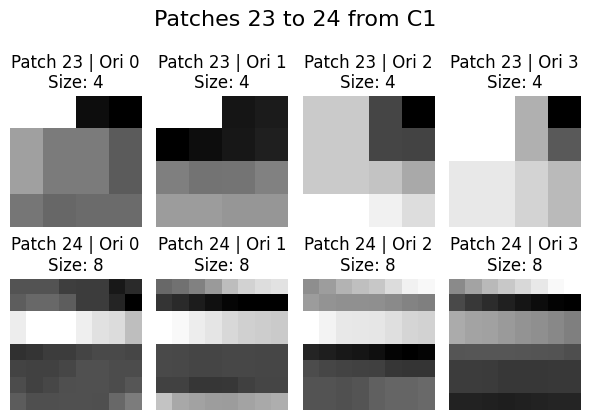

based on size
  size: 4: 249 patch
  size: 8: 250 patch
  size: 12: 262 patch
  size: 16: 239 patch


In [24]:
patches,meta = build_four_orientation_patch_pool(c1_maps)

visualize_patches_range(patches, meta, start=23, end=25)


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import defaultdict
from typing import List, Dict
import hashlib
import numpy as np

Tensor = torch.Tensor

class S2Flexible(nn.Module):
    def __init__(self,
                 patches: List[torch.Tensor],
                 activation: str = "euclidean",
                 sigma: float = 5.0):
        super().__init__()
        self.activation = activation
        self.sigma = sigma
        self._cache = {}

        groups: Dict[int, List[int]] = defaultdict(list)
        for idx, p in enumerate(patches):
            ps = p.shape[-1]
            groups[ps].append(idx)

        self.size_groups = {}
        self.order = []
        offset_map = {}

        for ps, indices in sorted(groups.items()):
            group_patches = torch.stack([patches[i] for i in indices])
            n, n_ori, _, _ = group_patches.shape

            conv = nn.Conv2d(
                in_channels=n_ori,
                out_channels=n_ori * n,
                kernel_size=ps,
                padding=ps // 2,
                groups=n_ori,
                bias=False
            )
            conv.weight.data = group_patches.permute(1, 0, 2, 3).reshape(n_ori * n, 1, ps, ps)

            uniform = nn.Conv2d(1, 1, ps, padding=ps // 2, bias=False)
            nn.init.constant_(uniform.weight, 1)

            patch_sum_sq = nn.Parameter((group_patches ** 2).sum(dim=(1, 2, 3)))

            for p in conv.parameters():
                p.requires_grad = False
            uniform.weight.requires_grad = False
            patch_sum_sq.requires_grad = False

            self.add_module(f"conv_{ps}", conv)
            self.add_module(f"uni_{ps}", uniform)
            self.register_parameter(f"psum_{ps}", patch_sum_sq)

            self.size_groups[ps] = dict(
                indices=indices,
                conv=conv,
                uniform=uniform,
                p_sum=patch_sum_sq,
                n_patches=len(indices)
            )

            for idx in indices:
                offset_map[idx] = len(self.order)
                self.order.append(idx)

        self.order = torch.tensor(self.order)
        self.inv_order = torch.argsort(self.order)
        self.total_patches = len(self.order)
        self.num_orientations = 4

    def _hash_tensor(self, t: torch.Tensor) -> str:
        arr = (t.detach().cpu().numpy() * 255).astype(np.uint8)
        return hashlib.md5(arr.tobytes()).hexdigest()

    def _distance_block(self, c1: Tensor, grp: Dict) -> Tensor:
        conv = grp["conv"]
        uniform = grp["uniform"]
        p_sum = grp["p_sum"]
        n_p = grp["n_patches"]

        wp = conv(c1)
        H, W = wp.shape[-2:]
        wp = wp.view(c1.shape[0], self.num_orientations, n_p, H, W).sum(dim=1)

        w2 = uniform(torch.sum(c1 ** 2, dim=1, keepdim=True))
        dist = w2 - 2 * wp + p_sum[None, :, None, None]

        if self.activation == "gaussian":
            dist = torch.exp(-dist / (2 * self.sigma ** 2))
        else:
            dist = F.relu(dist)
            dist = torch.sqrt(dist)
        return dist
    def clear_cache(self):
        self._cache.clear()



    def forward(self, c1_batch: torch.Tensor) -> torch.Tensor:
        key = self._hash_tensor(c1_batch)
        if key in self._cache:
            return self._cache[key]

        outputs = []
        for ps, grp in self.size_groups.items():
            outputs.append(self._distance_block(c1_batch, grp))

        s2_concat = torch.cat(outputs, dim=1)
        s2_concat = s2_concat[:, self.inv_order, :, :]

        self._cache[key] = s2_concat
        return s2_concat


In [29]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def test_s2_patch_similarity(image_a_path, image_b_path, total_patches=200):
    s1_layer = FullS1Layer()
    c1_layer = C1Layer()

    img_a = preprocess_image(image_a_path)
    s1_a = s1_layer(img_a)
    c1_a = c1_layer(s1_a)

    patches, meta = build_four_orientation_patch_pool(c1_a, total_patches=total_patches)
    print(f"exctration {len(patches)} from A")

    img_b = preprocess_image(image_b_path)
    s1_b = s1_layer(img_b)
    c1_b = c1_layer(s1_b)

    min_h = min([c1_b[i].shape[-2] for i in range(32)])
    min_w = min([c1_b[i].shape[-1] for i in range(32)])
    resized_c1 = [
        F.interpolate(c1_b[i], size=(min_h, min_w), mode='bilinear')[0] for i in range(32)
    ]
    c1_b_stack = torch.stack(resized_c1).reshape(4, 8, min_h, min_w).mean(dim=1).unsqueeze(0)  # [1, 4, H, W]

    s2_layer = S2Flexible(patches, activation="euclidean")
    s2_output = s2_layer(c1_b_stack)  # [1, num_patches, H, W]
    print(f"out put S2: {s2_output.shape}")

    patch_id = 50
    similarity_map = s2_output[0, patch_id].detach().numpy()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_b[0, 0], cmap='gray')
    plt.title("Input Image B")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(similarity_map, cmap='hot')
    plt.title(f"S2 Map (Patch {patch_id})")
    plt.axis("off")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


exctration 200 from A
Band 0 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 34, 79])
Band 1 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 27, 63])
Band 2 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 22, 52])
Band 3 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 19, 45])
Band 4 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 16, 39])
Band 5 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 14, 34])
Band 6 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 13, 31])
Band 7 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 11, 28])
Band 8 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 34, 79])
Band 9 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 27, 63])
Band 10 | C1 map shape: torch.Size([1, 1, 140, 323]) → Pooled: torch.Size([1, 1, 22, 52]

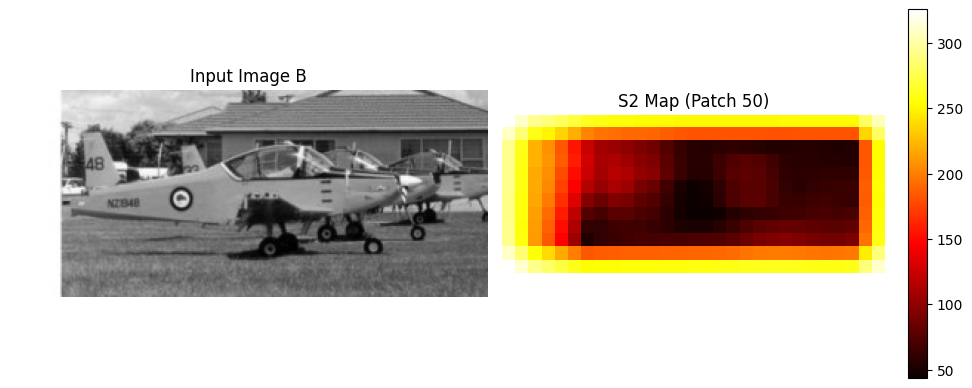

In [30]:
test_s2_patch_similarity(
    image_a_path="/content/caltech101/101_ObjectCategories/airplanes/image_0001.jpg",
    image_b_path="/content/caltech101/101_ObjectCategories/airplanes/image_0004.jpg",
    total_patches=200
)


exctration 200 from A
Band 0 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 34, 47])
Band 1 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 27, 37])
Band 2 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 22, 31])
Band 3 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 19, 26])
Band 4 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 16, 23])
Band 5 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 14, 20])
Band 6 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 13, 18])
Band 7 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 11, 16])
Band 8 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 34, 47])
Band 9 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 27, 37])
Band 10 | C1 map shape: torch.Size([1, 1, 140, 194]) → Pooled: torch.Size([1, 1, 22, 31]

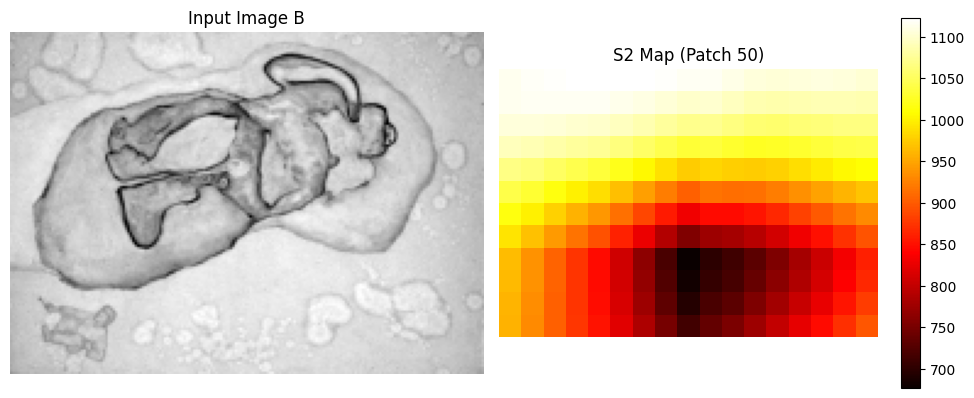

In [31]:
test_s2_patch_similarity(
    image_a_path="/content/caltech101/101_ObjectCategories/airplanes/image_0001.jpg",
    image_b_path="/content/caltech101/101_ObjectCategories/BACKGROUND_Google/image_0019.jpg",
    total_patches=200
)


In [ ]:
class C2(nn.Module):
    def __init__(self, activation='euclidean'):
        super().__init__()
        self.activation = activation

    def forward(self, s2_out: torch.Tensor) -> torch.Tensor:
        if self.activation == "euclidean":
            return torch.amin(s2_out, dim=(-2, -1))  # [B, N]
        else:
            return torch.amax(s2_out, dim=(-2, -1))  # [B, N]


In [ ]:
def test_c2_gaussian():
    from torch import tensor
    import torch.nn as nn
    c2 = C2(activation='gaussian')
    s2_fake = tensor([
        [
            [[0.1, 0.8], [0.5, 0.4]],  # patch 0  max=0.8
            [[0.3, 0.2], [0.6, 0.4]],  # patch 1  max=0.6
        ]
    ])  # shape [1, 2, 2, 2]
    expected = tensor([[0.8, 0.6]])
    output = c2(s2_fake)
    print("C2 Output (gaussian):", output)
    assert torch.allclose(output, expected)
    print("Gaussian C2 passed the test.")



In [ ]:
def test_c2_euclidean():
    from torch import tensor
    import torch.nn as nn
    c2 = C2(activation='euclidean')
    s2_fake = tensor([
        [
            [[1.0, 2.0], [3.0, 4.0]],  # patch 0 min=1.0
            [[5.0, 6.0], [7.0, 8.0]],  # patch 1 min=5.0
            [[9.0, 4.0], [6.0, 7.0]]   # patch 2 min=4.0
        ]
    ])  # shape [1, 3, 2, 2]
    expected = tensor([[1.0, 5.0, 4.0]])
    output = c2(s2_fake)
    print("C2 Output:", output)
    assert torch.allclose(output, expected)
    print(" C2 passed the test.")


In [ ]:
test_c2_euclidean()
test_c2_gaussian()

C2 Output: tensor([[1., 5., 4.]])
 C2 passed the test.
C2 Output (gaussian): tensor([[0.8000, 0.6000]])
Gaussian C2 passed the test.


In [ ]:
def test_c2_on_real_images(image_a_path, image_b_path, total_patches=100, activation='euclidean'):
    s1_layer = FullS1Layer()
    c1_layer = C1Layer()

    img_a = preprocess_image(image_a_path)
    s1_a = s1_layer(img_a)
    c1_a = c1_layer(s1_a)
    patches, meta = build_four_orientation_patch_pool(c1_a, total_patches=total_patches)

    img_b = preprocess_image(image_b_path)
    s1_b = s1_layer(img_b)
    c1_b = c1_layer(s1_b)

    import torch.nn.functional as F
    min_h = min([c1_b[i].shape[-2] for i in range(32)])
    min_w = min([c1_b[i].shape[-1] for i in range(32)])
    resized_c1 = [
        F.interpolate(c1_b[i], size=(min_h, min_w), mode='bilinear')[0] for i in range(32)
    ]
    c1_b_stack = torch.stack(resized_c1).reshape(4, 8, min_h, min_w).mean(dim=1).unsqueeze(0)  # [1, 4, H, W]

    s2 = S2Flexible(patches, activation=activation)
    c2 = C2(activation=activation)

    s2_out = s2(c1_b_stack)
    c2_out = c2(s2_out)  # [1, total_patches]

    print(f"C2 Output shape: {c2_out.shape}")
    print(f"Top 5 patches with {'lowest distance' if activation=='euclidean' else 'highest similarity'}:")

    values, indices = (torch.topk(-c2_out[0], 100) if activation == "euclidean"
                       else torch.topk(c2_out[0], 100))

    for i, (v, idx) in enumerate(zip(values, indices)):
        score = -v.item() if activation == "euclidean" else v.item()
        print(f"  ➤ Rank {i+1}: Patch {idx.item()} | Score: {score:.4f}")


In [ ]:
test_c2_on_real_images(
    image_a_path="/content/caltech_subset/content/my_caltech_subset/airplanes/image_0001.jpg",
    image_b_path="/content/caltech_subset/content/my_caltech_subset/airplanes/image_0004.jpg",
    total_patches=100,
    activation='euclidean'  #'gaussian'
)

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 34, 83])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 27, 66])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 22, 55])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 19, 47])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 16, 41])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 14, 36])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 13, 32])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 11, 29])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 34, 83])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 27, 66])
[DEBUG] Band 10 | C1 map shape

In [ ]:
test_c2_on_real_images(
    image_a_path="/content/caltech_subset/content/my_caltech_subset/airplanes/image_0001.jpg",
    image_b_path="/content/caltech_subset/content/my_caltech_subset/BACKGROUND_Google/image_0008.jpg",
    total_patches=100,
    activation='euclidean'

)

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 34, 83])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 27, 66])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 22, 55])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 19, 47])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 16, 41])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 14, 36])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 13, 32])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 11, 29])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 34, 83])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 339]) → Pooled: torch.Size([1, 1, 27, 66])
[DEBUG] Band 10 | C1 map shape

In [ ]:
import torch
import torch.nn.functional as F

def combine_c1_by_orientation(c1_maps):

    ori_maps = []
    for ori in range(4):
        band_tensors = c1_maps[ori*8 : (ori+1)*8]
        Hmin = min(t.shape[2] for t in band_tensors)
        Wmin = min(t.shape[3] for t in band_tensors)
        band_resized = [F.interpolate(t, size=(Hmin, Wmin),
                                      mode="bilinear",
                                      align_corners=False)
                        for t in band_tensors]
        # max
        ori_map = torch.max(torch.stack(band_resized, dim=0), dim=0)[0]
        ori_maps.append(ori_map)

    #  [1,4,Hmin,Wmin]
    c1_4ch = torch.cat(ori_maps, dim=1)
    return c1_4ch


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import hashlib
from PIL import Image

class HMAX(nn.Module):
    def __init__(self, patches, activation="euclidean", sigma=1.0):
        super().__init__()
        self.s1 = FullS1Layer()
        self.c1 = C1Layer()
        self.s2 = S2Flexible(patches, activation=activation, sigma=sigma)
        self.c2 = C2(activation=activation)

        self._memory_cache = {}  # RAM-based cache

    def preprocess(self, img: torch.Tensor) -> torch.Tensor:
        if isinstance(img, Image.Image):
            img = img.convert("L")
            w, h = img.size
            new_h = 140
            new_w = int((new_h / h) * w)
            img = img.resize((new_w, new_h), Image.BILINEAR)
            img_tensor = torch.tensor(np.array(img), dtype=torch.float32) / 255.0
            img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
        elif isinstance(img, torch.Tensor):
            assert img.ndim == 3  # [1, H, W]
            img_tensor = img.unsqueeze(0)
        else:
            raise ValueError("Unsupported image format")
        return img_tensor

    def _make_hash(self, img) -> str:
        if isinstance(img, Image.Image):
            img = img.convert("L").resize((140, int(140 * img.width / img.height)))
            arr = np.array(img).astype(np.uint8)
        elif isinstance(img, torch.Tensor):
            arr = img.numpy().astype(np.uint8)
        else:
            raise ValueError("Unsupported image type for hashing")
        return hashlib.md5(arr.tobytes()).hexdigest()
    def clear_cache(self):
            self._memory_cache.clear()
            if hasattr(self.s2, "clear_cache"):
                self.s2.clear_cache()
    def forward(self, img_input):
        key = self._make_hash(img_input)

        # If cached in memory, return
        if key in self._memory_cache:
            return self._memory_cache[key]

        # Else compute HMAX forward pass
        x = self.preprocess(img_input)
        s1_out = self.s1(x)
        c1_out = self.c1(s1_out)

        min_h = min([c.shape[-2] for c in c1_out])
        min_w = min([c.shape[-1] for c in c1_out])
        resized = [F.interpolate(c, size=(min_h, min_w), mode='bilinear') for c in c1_out]
        c1_stack = torch.stack(resized).reshape(4, 8, min_h, min_w).mean(dim=1).unsqueeze(0)

        s2_out = self.s2(c1_stack)
        c2_out = self.c2(s2_out).squeeze(0)  # shape: [num_patches]

        # Cache in RAM
        self._memory_cache[key] = c2_out

        return c2_out


In [ ]:
import torch
import numpy as np
from PIL import Image
import torch.nn.functional as F

def extract_patches_from_image(
    img,
    s1_layer,
    c1_layer,
    total_patches=300,
    patch_sizes=(4, 8, 12, 16)
):
    """
    Extract patches from a single image to be used in the S2 layer.

    Parameters
    ----------
    img : PIL.Image or Tensor
        Input image (will be converted to grayscale and resized to H=140)
    s1_layer : nn.Module
        Pre-initialized FullS1Layer
    c1_layer : nn.Module
        Pre-initialized C1Layer
    total_patches : int
        Number of patches to extract
    patch_sizes : tuple
        Possible patch sizes

    Returns
    -------
    patches : list of Tensors [4, ps, ps]
    meta : list of dict (size, band, x, y)
    """
    # 1. Preprocess image
    if isinstance(img, Image.Image):
        img = img.convert("L")
        w, h = img.size
        new_h = 140
        new_w = int((new_h / h) * w)
        img = img.resize((new_w, new_h), Image.BILINEAR)
        img_tensor = torch.tensor(np.array(img), dtype=torch.float32) / 255.0
        img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
    elif isinstance(img, torch.Tensor):
        assert img.ndim == 3  # [1, H, W]
        img_tensor = img.unsqueeze(0)
    else:
        raise ValueError("Unsupported image type")

    # 2. Run through S1 → C1
    with torch.no_grad():
        s1_out = s1_layer(img_tensor)
        c1_out = c1_layer(s1_out)

    # 3. Extract patches from C1
    from random import randint, choice

    ori_band = [[c1_out[ori*8 + b] for b in range(8)] for ori in range(4)]
    band_hw  = [ori_band[0][b].shape[2:] for b in range(8)]

    patches, meta, tries = [], [], 0
    max_tries = 50_000

    while len(patches) < total_patches and tries < max_tries:
        tries += 1
        ps = choice(patch_sizes)

        valid_bands = [b for b, (H, W) in enumerate(band_hw) if H >= ps and W >= ps]
        if not valid_bands:
            continue

        band = choice(valid_bands)
        H, W = band_hw[band]
        y = randint(0, H - ps)
        x = randint(0, W - ps)

        patch = torch.cat(
            [ori_band[ori][band][:, :, y:y+ps, x:x+ps] for ori in range(4)],
            dim=1  # → [1, 4, ps, ps]
        ).squeeze(0)  # [4, ps, ps]

        patches.append(patch)
        meta.append(dict(size=ps, band=band, y=y, x=x))

    if len(patches) < total_patches:
        print(f" Only {len(patches)}/{total_patches} patches collected.")

    return patches, meta


In [ ]:
import glob
import random
from PIL import Image
import numpy as np
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
# Constants and dataset config
DATASET_ROOT = "/content/caltech_subset/content/my_caltech_subset"
POS_CLASS    = "airplanes"
NEG_CLASS    = "BACKGROUND_Google"
TRAIN_POS    = 40
TRAIN_NEG    = 50
TEST_POS     = 50
TEST_NEG     = 50
TOTAL_PATCH  = 1000  # Reduced for memory safety
HMAX_SIGMA   = 5.0

# Step 1: Collect positive and negative image paths
pos_files = sorted(glob.glob(os.path.join(DATASET_ROOT, POS_CLASS, "*.jpg")))
neg_files = sorted(glob.glob(os.path.join(DATASET_ROOT, NEG_CLASS, "*.jpg")))

random.shuffle(pos_files)
random.shuffle(neg_files)

train_files = pos_files[:TRAIN_POS] + neg_files[:TRAIN_NEG]
test_files  = pos_files[TRAIN_POS:TRAIN_POS + TEST_POS] + \
              neg_files[TRAIN_NEG:TRAIN_NEG + TEST_NEG]

train_labels = [1]*TRAIN_POS + [0]*TRAIN_NEG
test_labels  = [1]*TEST_POS  + [0]*TEST_NEG

# Step 2: Initialize HMAX components
s1_layer = FullS1Layer()
c1_layer = C1Layer()

# Step 3: Extract patches from positive training images only
patches = []
positive_train_images = [Image.open(f) for f in pos_files[:TRAIN_POS]]
for img in tqdm(positive_train_images, desc="Extracting patches from positives"):
    ps, _ = extract_patches_from_image(
        img, s1_layer, c1_layer,
        total_patches=TOTAL_PATCH // TRAIN_POS
    )
    patches.extend(ps)

# Step 4: Initialize full HMAX model with extracted patches
hmax_model = HMAX(patches, activation="euclidean", sigma=HMAX_SIGMA)

# Step 5: Extract features from training images
train_features = []
for path in tqdm(train_files, desc="Extracting train features"):
    img = Image.open(path)
    feat = hmax_model(img).numpy()
    train_features.append(feat)
train_features = np.stack(train_features)

# Step 6: Train SVM classifier
svm_clf = SVC(kernel="linear", C=1.0)
svm_clf.fit(train_features, train_labels)

# Step 7: Extract features from test images
test_features = []
for path in tqdm(test_files, desc="Extracting test features"):
    img = Image.open(path)
    feat = hmax_model(img).numpy()
    test_features.append(feat)
test_features = np.stack(test_features)

# Step 8: Predict and evaluate test accuracy
test_preds = svm_clf.predict(test_features)
accuracy = accuracy_score(test_labels, test_preds)
print(f"\nRESULTS  (pos={POS_CLASS}  vs  neg=background)")
print(f" Test accuracy : {accuracy * 100:.2f}%")


Extracting patches from positives:   2%|▎         | 1/40 [00:17<11:19, 17.43s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 34, 90])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 27, 72])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 22, 59])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 19, 51])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 16, 44])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 14, 39])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 13, 35])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 11, 32])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 34, 90])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 365]) → Pooled: torch.Size([1, 1, 27, 72])
[DEBUG] Band 10 | C1 map shape

Extracting patches from positives:   5%|▌         | 2/40 [00:38<12:15, 19.35s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 34, 85])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 27, 67])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 22, 56])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 19, 48])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 16, 42])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 14, 37])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 13, 33])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 11, 30])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 34, 85])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 344]) → Pooled: torch.Size([1, 1, 27, 67])
[DEBUG] Band 10 | C1 map shape

Extracting patches from positives:   8%|▊         | 3/40 [00:58<12:10, 19.74s/it]

...

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 34, 45])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 27, 36])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 22, 30])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 19, 25])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 16, 22])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 14, 19])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 13, 17])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 11, 15])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 34, 45])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 186]) → Pooled: torch.Size([1, 1, 27, 36])
[DEBUG] Band 10 | C1 map shape

Extracting test features:  99%|█████████▉| 99/100 [21:17<00:07,  7.54s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 34, 49])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 27, 39])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 22, 32])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 19, 27])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 16, 24])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 14, 21])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 13, 19])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 11, 17])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 34, 49])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 201]) → Pooled: torch.Size([1, 1, 27, 39])
[DEBUG] Band 10 | C1 map shape

Extracting test features: 100%|██████████| 100/100 [21:27<00:00, 12.88s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 34, 51])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 27, 40])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 22, 33])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 19, 28])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 16, 25])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 14, 22])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 13, 19])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 11, 17])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 34, 51])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 208]) → Pooled: torch.Size([1, 1, 27, 40])
[DEBUG] Band 10 | C1 map shape

In [ ]:
import torch
import random
import numpy as np
import hashlib
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

class GeneticPatchSelector:
    def __init__(self, patch_pool, train_images, train_labels, test_images, test_labels,
                 hmax_template, population_size=5, generations=5, mutation_prob=0.05):
        self.patch_pool = patch_pool
        self.N = len(patch_pool)
        self.train_images = train_images
        self.train_labels = train_labels
        self.test_images = test_images
        self.test_labels = test_labels
        self.hmax_template = hmax_template
        self.population_size = population_size
        self.generations = generations
        self.mutation_prob = mutation_prob
        self._fitness_cache = {}  # RAM cache for fitness values

    def _init_population(self):
        return [torch.randint(0, 2, (self.N,), dtype=torch.bool) for _ in range(self.population_size)]

    def _hash_chromosome(self, chromosome):
        return hashlib.md5(chromosome.numpy().tobytes()).hexdigest()

    def _evaluate(self, chromosome):
        hash_key = self._hash_chromosome(chromosome)
        if hash_key in self._fitness_cache:
            return self._fitness_cache[hash_key]

        selected_indices = chromosome.nonzero().flatten().tolist()
        if len(selected_indices) == 0:
            return float('inf')

        patches_selected = [self.patch_pool[i] for i in selected_indices]
        hmax = self.hmax_template(patches_selected)

        example_feat = hmax(self.train_images[0]).numpy()
        feature_vector_length = len(example_feat)

        selected_indices = [i for i in selected_indices if i < feature_vector_length]
        if len(selected_indices) == 0:
            return float('inf')

        train_feats = [hmax(img).numpy()[selected_indices] for img in self.train_images]
        test_feats  = [hmax(img).numpy()[selected_indices] for img in self.test_images]

        clf = SVC(kernel="linear", C=1.0)
        clf.fit(train_feats, self.train_labels)
        preds = clf.predict(test_feats)
        acc = accuracy_score(self.test_labels, preds)
        fitness = 1 - acc

        self._fitness_cache[hash_key] = fitness

        print("\n[DEBUG] Evaluation for Chromosome:")
        print(f"  → Selected patches: {len(selected_indices)} | Indices: {selected_indices[:10]}{' ...' if len(selected_indices) > 10 else ''}")
        for i, (pred, label) in enumerate(zip(preds, self.test_labels)):
            print(f"     Eval Image {i+1:02d} | Predicted: {pred} | True: {label}")

        return fitness


    def _selection(self, population, fitnesses):
        sorted_pop = [x for _, x in sorted(zip(fitnesses, population), key=lambda x: x[0])]
        return sorted_pop[:2]

    def _crossover(self, parent1, parent2):
        point = random.randint(1, self.N - 1)
        child1 = torch.cat([parent1[:point], parent2[point:]])
        child2 = torch.cat([parent2[:point], parent1[point:]])
        return child1, child2

    def _mutate(self, chromosome):
        for i in range(len(chromosome)):
            if random.random() < self.mutation_prob:
                chromosome[i] = ~chromosome[i]
        return chromosome

    def run(self):
        population = self._init_population()

        for gen in range(self.generations):
            print(f"\n================== Generation {gen+1} ==================")
            fitnesses = [self._evaluate(ind) for ind in population]
            print(f"  ✓ Best fitness: {min(fitnesses):.4f}")

            selected = self._selection(population, fitnesses)
            new_population = selected[:]

            while len(new_population) < self.population_size:
                p1, p2 = random.sample(selected, 2)
                c1, c2 = self._crossover(p1, p2)
                new_population.extend([self._mutate(c1), self._mutate(c2)])

            population = new_population[:self.population_size]

        final_fitnesses = [self._evaluate(ind) for ind in population]
        best_idx = np.argmin(final_fitnesses)
        best_chromosome = population[best_idx]
        print(f"\n Final Best Patch Subset | Accuracy: {1 - final_fitnesses[best_idx]:.4f}")
        return best_chromosome

In [ ]:
import os
import glob
import random
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# ---------------------------- Config ----------------------------------
DATASET_ROOT = "/content/caltech_subset/content/my_caltech_subset"
POS_CLASS    = "airplanes"
NEG_CLASS    = "BACKGROUND_Google"
TRAIN_POS    = 1
TRAIN_NEG    = 50
EVAL_POS     = 50
EVAL_NEG     = 50
TEST_POS     = 50
TEST_NEG     = 50
TOTAL_PATCH  = 1000
HMAX_SIGMA   = 5.0

# Load file paths
pos_files = sorted(glob.glob(os.path.join(DATASET_ROOT, POS_CLASS, "*.jpg")))
neg_files = sorted(glob.glob(os.path.join(DATASET_ROOT, NEG_CLASS, "*.jpg")))
random.shuffle(pos_files)
random.shuffle(neg_files)

train_files = pos_files[:TRAIN_POS] + neg_files[:TRAIN_NEG]
eval_files  = pos_files[TRAIN_POS:TRAIN_POS + EVAL_POS] + \
              neg_files[TRAIN_NEG:TRAIN_NEG + EVAL_NEG]
test_files  = pos_files[TRAIN_POS + EVAL_POS:TRAIN_POS + EVAL_POS + TEST_POS] + \
              neg_files[TRAIN_NEG + EVAL_NEG:TRAIN_NEG + EVAL_NEG + TEST_NEG]

train_labels = [1]*TRAIN_POS + [0]*TRAIN_NEG
eval_labels  = [1]*EVAL_POS  + [0]*EVAL_NEG
test_labels  = [1]*TEST_POS  + [0]*TEST_NEG

#  Extract patches
s1_layer = FullS1Layer()
c1_layer = C1Layer()

patches = []
positive_train_images = [Image.open(f) for f in pos_files[:TRAIN_POS]]
for img in tqdm(positive_train_images, desc="Extracting patches from positives"):
    ps, _ = extract_patches_from_image(
        img, s1_layer, c1_layer,
        total_patches=TOTAL_PATCH // TRAIN_POS
    )
    patches.extend(ps)

# GA-based Patch Selection

eval_images = [Image.open(f) for f in eval_files]
test_images = [Image.open(f) for f in test_files]


# Template for HMAX (with selected patches to be filled during GA)
def hmax_template(patch_subset):
    return HMAX(patch_subset, activation="euclidean", sigma=HMAX_SIGMA)

selector = GeneticPatchSelector(
    patch_pool=patches,
    train_images=[Image.open(f) for f in train_files],
    train_labels=train_labels,
    test_images=eval_images,
    test_labels=eval_labels,
    hmax_template=hmax_template,
    population_size=5,
    generations=5,
    mutation_prob=0.1
)

best_chromosome = selector.run()



Extracting patches from positives: 100%|██████████| 1/1 [00:25<00:00, 25.99s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 34, 106])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 27, 85])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 22, 70])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 19, 60])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 16, 52])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 14, 46])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 13, 42])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 11, 38])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 34, 106])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 430]) → Pooled: torch.Size([1, 1, 27, 85])
[DEBUG] Band 10 | C1 map sha

Streaming output truncated to the last 5000 lines.
[DEBUG] Band 19 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 19, 31])
[DEBUG] Band 20 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 16, 27])
[DEBUG] Band 21 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 14, 24])
[DEBUG] Band 22 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 13, 22])
[DEBUG] Band 23 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 11, 19])
[DEBUG] Band 24 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 34, 56])
[DEBUG] Band 25 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 27, 45])
[DEBUG] Band 26 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 22, 37])
[DEBUG] Band 27 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pooled: torch.Size([1, 1, 19, 31])
[DEBUG] Band 28 | C1 map shape: torch.Size([1, 1, 140, 230]) → Pool

Extracting test features:   0%|          | 0/100 [00:15<?, ?it/s]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 34, 83])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 27, 66])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 22, 55])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 19, 47])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 16, 41])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 14, 36])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 13, 32])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 11, 29])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 34, 83])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 338]) → Pooled: torch.Size([1, 1, 27, 66])
[DEBUG] Band 10 | C1 map shape

IndexError: index 477 is out of bounds for axis 0 with size 477

In [ ]:
selected_indices = best_chromosome.nonzero().flatten().tolist()
selected_patches = [patches[i] for i in selected_indices]
hmax_final = HMAX(selected_patches, activation="euclidean", sigma=HMAX_SIGMA)

test_features = []
for img in tqdm(test_images, desc="Extracting test features"):
    feat = hmax_final(img).numpy()
    test_features.append(feat)
test_features = np.stack(test_features)

# Train SVM on train set with best patches
train_features = []
for path in tqdm(train_files, desc="Extracting train features"):
    img = Image.open(path)
    feat = hmax_final(img).numpy()
    train_features.append(feat)
train_features = np.stack(train_features)

svm_clf = SVC(kernel="linear", C=1.0)
svm_clf.fit(train_features, train_labels)

test_preds = svm_clf.predict(test_features)
accuracy = accuracy_score(test_labels, test_preds)
print(f"\nFINAL TEST ACCURACY : {accuracy * 100:.2f}%")

Extracting test features:   2%|▏         | 2/100 [00:24<19:53, 12.18s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 34, 94])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 27, 75])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 22, 62])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 19, 53])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 16, 46])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 14, 41])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 13, 37])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 11, 33])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 34, 94])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 380]) → Pooled: torch.Size([1, 1, 27, 75])
[DEBUG] Band 10 | C1 map shape

Extracting test features:   3%|▎         | 3/100 [00:44<25:07, 15.54s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 34, 91])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 27, 73])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 22, 60])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 19, 51])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 16, 45])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 14, 40])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 13, 36])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 11, 32])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 34, 91])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 370]) → Pooled: torch.Size([1, 1, 27, 73])
[DEBUG] Band 10 | C1 map shape

Extracting test features:   5%|▌         | 5/100 [01:02<19:55, 12.59s/it]

...

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 34, 58])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 27, 46])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 22, 38])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 19, 32])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 16, 28])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 14, 25])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 13, 22])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 11, 20])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 34, 58])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 236]) → Pooled: torch.Size([1, 1, 27, 46])
[DEBUG] Band 10 | C1 map shape

Extracting test features: 100%|██████████| 100/100 [17:08<00:00, 10.29s/it]


[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 34, 34])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 27, 27])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 22, 22])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 19, 19])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 16, 16])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 14, 14])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 13, 13])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 11, 11])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 34, 34])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 140]) → Pooled: torch.Size([1, 1, 27, 27])
[DEBUG] Band 10 | C1 map shape

Extracting train features: 100%|██████████| 51/51 [00:03<00:00, 16.02it/s]



FINAL TEST ACCURACY : 67.00%


In [ ]:
def evaluate(hmax_model, name):
    train_features = [hmax_model(Image.open(f)).numpy() for f in tqdm(train_files, desc=f"Train - {name}")]
    test_features = [hmax_model(img).numpy() for img in tqdm(test_images, desc=f"Test - {name}")]
    clf = SVC(kernel="linear", C=1.0)
    clf.fit(train_features, train_labels)
    preds = clf.predict(test_features)
    acc = accuracy_score(test_labels, preds)
    print(f"{name} ACCURACY ({len(hmax_model.s2.order)} patches): {acc * 100:.2f}%")
    return float(acc)
import re

def extract_image_ids_with_class(filepaths):
    ids = []
    for f in filepaths:
        basename = os.path.basename(f)
        img_id = int(os.path.splitext(basename)[0].split("_")[-1])
        if "airplanes" in f:
            ids.append(f"pos_{img_id}")
        elif "BACKGROUND_Google" in f:
            ids.append(f"neg_{img_id}")
        else:
            ids.append(f"unk_{img_id}")
    return ids




In [ ]:
import os
import glob
import random

DATASET_ROOT = "/content/caltech_subset/content/my_caltech_subset"
POS_CLASS    = "airplanes"
NEG_CLASS    = "BACKGROUND_Google"
TRAIN_POS    = 3
TRAIN_NEG    = 50
EVAL_POS     = 40
EVAL_NEG     = 40
TEST_POS     = 50
TEST_NEG     = 50
TOTAL_PATCH  = 1000
HMAX_SIGMA   = 5.0

def clear_ram_cache(hmax_model):
    if hasattr(hmax_model, "_memory_cache"):
        hmax_model._memory_cache.clear()
    if hasattr(hmax_model, "s2") and hasattr(hmax_model.s2, "_cache"):
        hmax_model.s2._cache.clear()



all_pos = sorted(glob.glob(os.path.join(DATASET_ROOT, POS_CLASS, "*.jpg")))
all_neg = sorted(glob.glob(os.path.join(DATASET_ROOT, NEG_CLASS, "*.jpg")))
random.shuffle(all_pos)
random.shuffle(all_neg)

pos_train = all_pos[:TRAIN_POS]
pos_eval  = all_pos[TRAIN_POS:TRAIN_POS + EVAL_POS]
pos_test  = all_pos[TRAIN_POS + EVAL_POS:TRAIN_POS + EVAL_POS + TEST_POS]

neg_train = all_neg[:TRAIN_NEG]
neg_eval  = all_neg[TRAIN_NEG:TRAIN_NEG + EVAL_NEG]
neg_test  = all_neg[TRAIN_NEG + EVAL_NEG:TRAIN_NEG + EVAL_NEG + TEST_NEG]

train_files = pos_train + neg_train
eval_files  = pos_eval + neg_eval
test_files  = pos_test + neg_test

train_labels = [1]*len(pos_train) + [0]*len(neg_train)
eval_labels  = [1]*len(pos_eval) + [0]*len(neg_eval)
test_labels  = [1]*len(pos_test) + [0]*len(neg_test)

train_ids = extract_image_ids_with_class(train_files)
eval_ids  = extract_image_ids_with_class(eval_files)
test_ids  = extract_image_ids_with_class(test_files)

print("\nImage IDs used in Train Set:", train_ids)
print("Image IDs used in Eval Set :", eval_ids)
print("Image IDs used in Test Set :", test_ids)


s1_layer = FullS1Layer()
c1_layer = C1Layer()

patches = []
positive_train_images = [Image.open(f) for f in pos_files[:TRAIN_POS]]
for img in tqdm(positive_train_images, desc="Extracting patches from positives"):
    ps, _ = extract_patches_from_image(
        img, s1_layer, c1_layer,
        total_patches=TOTAL_PATCH // TRAIN_POS
    )
    patches.extend(ps)
eval_images = [Image.open(f) for f in eval_files]
test_images = [Image.open(f) for f in test_files]

def hmax_template(patch_subset):
    return HMAX(patch_subset, activation="euclidean", sigma=HMAX_SIGMA)

selector = GeneticPatchSelector(
    patch_pool=patches,
    train_images=[Image.open(f) for f in train_files],
    train_labels=train_labels,
    test_images=eval_images,
    test_labels=eval_labels,
    hmax_template=hmax_template,
    population_size=5,
    generations=5,
    mutation_prob=0.1
)

best_chromosome = selector.run()
selected_indices = best_chromosome.nonzero().flatten().tolist()
patch_count = len(selected_indices)
patch_pool_size = len(patches)

if patch_count > patch_pool_size:
    patch_count = patch_pool_size
    print(f"\u26a0\ufe0f Reducing random sample size to {patch_pool_size} due to insufficient patches.")

selected_patches = [patches[i] for i in selected_indices]
random_indices = random.sample(range(len(patches)), patch_count)
random_patches = [patches[i] for i in random_indices]

hmax_ga = HMAX(selected_patches, activation="euclidean", sigma=HMAX_SIGMA)
acc_run1_plane_a_genetic_3 = evaluate(hmax_ga, "Genetic")
hmax_ga.clear_cache()

hmax_random = HMAX(random_patches, activation="euclidean", sigma=HMAX_SIGMA)
acc_run1_plane_a_random_3 = evaluate(hmax_random, "Random")
hmax_random.clear_cache()

hmax_all = HMAX(patches, activation="euclidean", sigma=HMAX_SIGMA)
acc_run1_plane_a_all_3 = evaluate(hmax_all, "All")
hmax_all.clear_cache()


hmax_ga.clear_cache()
hmax_random.clear_cache()
hmax_all.clear_cache()



Image IDs used in Train Set: ['pos_282', 'pos_434', 'pos_488', 'neg_333', 'neg_440', 'neg_392', 'neg_86', 'neg_275', 'neg_142', 'neg_182', 'neg_390', 'neg_154', 'neg_52', 'neg_115', 'neg_285', 'neg_364', 'neg_17', 'neg_16', 'neg_30', 'neg_223', 'neg_137', 'neg_387', 'neg_204', 'neg_160', 'neg_334', 'neg_40', 'neg_27', 'neg_360', 'neg_21', 'neg_273', 'neg_324', 'neg_319', 'neg_369', 'neg_280', 'neg_92', 'neg_150', 'neg_172', 'neg_106', 'neg_84', 'neg_462', 'neg_317', 'neg_322', 'neg_226', 'neg_389', 'neg_145', 'neg_434', 'neg_295', 'neg_62', 'neg_458', 'neg_130', 'neg_121', 'neg_264', 'neg_254']
Image IDs used in Eval Set : ['pos_704', 'pos_117', 'pos_229', 'pos_151', 'pos_273', 'pos_63', 'pos_165', 'pos_549', 'pos_87', 'pos_489', 'pos_301', 'pos_675', 'pos_739', 'pos_771', 'pos_475', 'pos_98', 'pos_260', 'pos_104', 'pos_135', 'pos_680', 'pos_36', 'pos_368', 'pos_500', 'pos_732', 'pos_484', 'pos_545', 'pos_419', 'pos_202', 'pos_149', 'pos_336', 'pos_121', 'pos_241', 'pos_72', 'pos_785'

Extracting patches from positives: 100%|██████████| 3/3 [00:00<00:00,  3.41it/s]


Streaming output truncated to the last 5000 lines.
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 19, 21])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 16, 18])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 14, 16])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 13, 14])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 11, 13])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 34, 37])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 27, 30])
[DEBUG] Band 10 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 22, 24])
[DEBUG] Band 11 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: torch.Size([1, 1, 19, 21])
[DEBUG] Band 12 | C1 map shape: torch.Size([1, 1, 140, 155]) → Pooled: tor

Test - Genetic:   1%|          | 1/100 [00:17<28:19, 17.17s/it]

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 34, 91])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 27, 72])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 22, 60])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 19, 51])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 16, 45])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 14, 40])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 13, 35])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 11, 32])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 34, 91])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 369]) → Pooled: torch.Size([1, 1, 27, 72])
[DEBUG] Band 10 | C1 map shape

...

[DEBUG] Band 0 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 34, 62])
[DEBUG] Band 1 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 27, 49])
[DEBUG] Band 2 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 22, 41])
[DEBUG] Band 3 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 19, 35])
[DEBUG] Band 4 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 16, 30])
[DEBUG] Band 5 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 14, 27])
[DEBUG] Band 6 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 13, 24])
[DEBUG] Band 7 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 11, 22])
[DEBUG] Band 8 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 34, 62])
[DEBUG] Band 9 | C1 map shape: torch.Size([1, 1, 140, 253]) → Pooled: torch.Size([1, 1, 27, 49])
[DEBUG] Band 10 | C1 map shape

Test - Random: 100%|██████████| 100/100 [00:06<00:00, 15.03it/s]


Random ACCURACY (493 patches): 75.00%


Test - All: 100%|██████████| 100/100 [00:07<00:00, 13.06it/s]

All ACCURACY (999 patches): 75.00%


In [ ]:
def clear_all_hmax_ram_caches(*models):
    for model in models:
        cleared = False

        if hasattr(model, "_memory_cache") and isinstance(model._memory_cache, dict):
            model._memory_cache.clear()
            cleared = True

        if hasattr(model, "s2") and hasattr(model.s2, "_cache") and isinstance(model.s2._cache, dict):
            model.s2._cache.clear()
            cleared = True

        if cleared:
            print(f"RAM cache for model {model.__class__.__name__} has been cleared.")
        else:
            print(f" No RAM cache found in model {model.__class__.__name__}.")


In [ ]:
import shutil
for cache_folder in ["s1_cache", "c1_cache", "s2_cache", "hmax_cache"]:
    if os.path.exists(cache_folder):
        shutil.rmtree(cache_folder)
        print(f"Deleted: {cache_folder}")

Deleted: s1_cache
Deleted: c1_cache
